# nb10 — выдерживает ли находка nb09 проверку

nb09 показал, что строгость ADF-отбора двигает edge, и что он **не** микроструктурный
шум (переживает задержку исполнения на час, сохраняется 72–102%). Но там же вылезли
два тревожных факта:

- топ-10 пар дают **47% итога, имея 3% сделок**, и в пяти из них участвует `TRBUSDT`,
  а в четырёх — `XMRUSDT`;
- при самых строгих порогах (t < −5) синтетика ведёт себя дико (от −0.53σ до +0.64σ
  на 12–443 сделках), то есть **сама база сравнения превращается в шум**, и «чистое
  превышение +0.85σ» из таблицы доверия не заслуживает.

Поэтому здесь — только проверки на прочность, без новых гипотез:

1. **Убрать по одному символу.** Если edge держится на TRB, он умрёт при его
   удалении. Проверка бесплатная: рефит и β считаются попарно, так что удаление
   символа из вселенной — это просто фильтр строк в таблице сделок.
2. **Бутстрэп по парам.** Доверительный интервал средней сделки, где единица
   ресэмплинга — пара, а не сделка.
3. **Разбить время.** Одинаково ли работает в 2024H1 / 2024H2 / 2025H1.
4. **Экономика того, что выжило.**

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
from _engine import *
from dataclasses import replace
from itertools import combinations

MIN_DVOL_M = 5.0
STABLES = ["USDCUSDT", "USDEUSDT", "DAIUSDT", "TUSDUSDT", "FDUSDUSDT"]
px = load_panel("close", "1h")
dv = load_panel("dollarvol", "1h")
daily_m = dv.median() * 24 / 1e6
liq = sorted([s for s in px.columns if daily_m[s] >= MIN_DVOL_M and s not in STABLES])
LP = np.log(px.loc[TRAIN[0]:TRAIN[1], liq]).iloc[:-1]
PAIRS = [((a, b) if daily_m[a] <= daily_m[b] else (b, a)) for a, b in combinations(liq, 2)]
bk = Book(LP, liq, PAIRS)
COST = ROUND_TRIP_BPS / 100

CFG = [(7, -4.6), (7, -4.2), (7, -3.8), (3, -3.8), (3, -4.2)]
TR = {}
for L in sorted({c[0] for c in CFG}):
    R = refit(bk, bk.nbars(L), -3.5)
    for L2, thr in [c for c in CFG if c[0] == L]:
        TR[(L2, thr)] = sweep(bk, replace(R, thr=thr), "REFIT", cost_pct=COST)
        d = TR[(L2, thr)]
        print(f"L={L2}д t<{thr}: {len(d)} сделок, gross {d.gross.mean():+.4f}%, "
              f"пар {d.pair.nunique()}")


def leg_syms(d):
    return sorted({s for p in d.pair.unique() for s in p.split("/")})

L=3д t<-3.8: 25653 сделок, gross +0.0599%, пар 903
L=3д t<-4.2: 11914 сделок, gross +0.0452%, пар 897


L=7д t<-4.6: 3179 сделок, gross +0.1241%, пар 694
L=7д t<-4.2: 7119 сделок, gross +0.0784%, пар 865


L=7д t<-3.8: 16055 сделок, gross +0.0508%, пар 902


## 1. Убрать по одному символу

Меряем среднюю сделку без каждого из 43 символов. Смысл в разбросе: если удаление
одного символа сдвигает результат на десятки процентов, «стратегия» — это на самом
деле эта пара инструментов, и на новых данных она может не повториться.

Плюс жёсткая версия: убрать **сразу все** символы из топа по вкладу.

УДАЛЕНИЕ ПО ОДНОМУ СИМВОЛУ


 L, дн  порог  база gross %  мин без символа     кто  макс без символа  медиана LOO  остаётся >0 без любого  падение от худшего, %
     3   -3.8        0.0599           0.0432 XMRUSDT            0.0729       0.0601                    True                   28.0
     3   -4.2        0.0452           0.0200 XMRUSDT            0.0666       0.0453                    True                   56.0
     7   -4.6        0.1241           0.0499 TRBUSDT            0.2257       0.1246                    True                   60.0
     7   -4.2        0.0784           0.0279 XMRUSDT            0.1163       0.0789                    True                   64.0
     7   -3.8        0.0508          -0.0076 XMRUSDT            0.0702       0.0517                   False                  115.0

L=7д t<-4.6: база +0.1241%. Пять самых влиятельных символов:
TRBUSDT       0.0743
XMRUSDT       0.0697
UNIUSDT       0.0229
PEOPLEUSDT    0.0187
OPUSDT        0.0139

без ['TRBUSDT', 'XMRUSDT']: 2257 сделок из 31

[saved] notebooks\statarb\_out\nb10_loo.png


WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb10_loo.png')

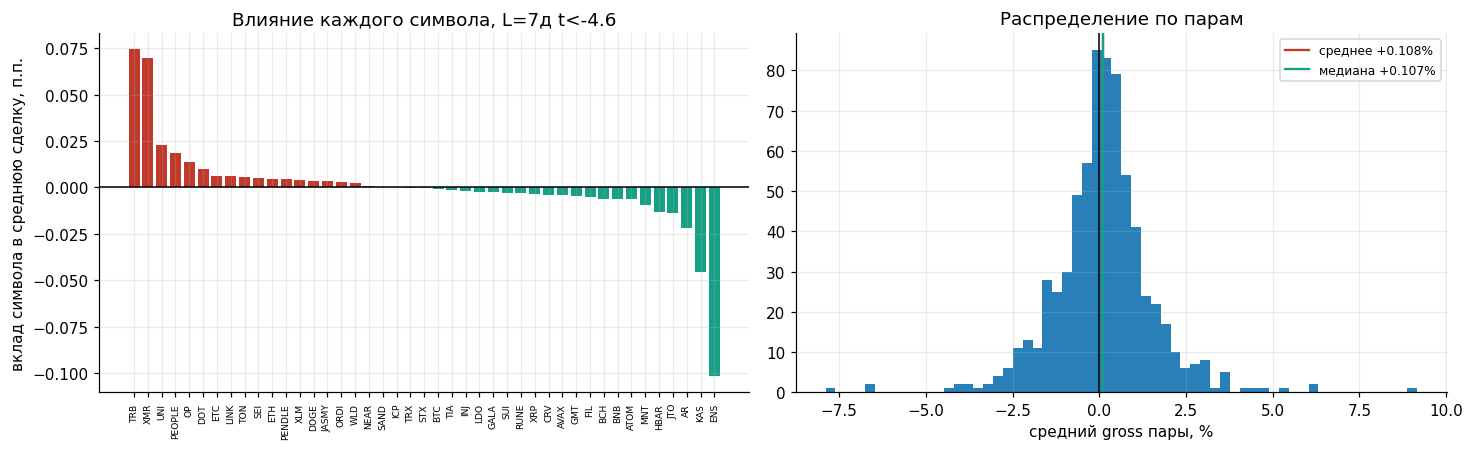

In [2]:
rows = []
for (L, thr), d in TR.items():
    base = d.gross.mean()
    loo = {}
    for s in leg_syms(d):
        m = ~d.pair.str.contains(s, regex=False)
        loo[s] = d[m].gross.mean() if m.sum() > 30 else np.nan
    loo = pd.Series(loo).dropna()
    worst = loo.idxmin()
    rows.append({"L, дн": L, "порог": thr, "база gross %": round(base, 4),
                 "мин без символа": round(loo.min(), 4), "кто": worst,
                 "макс без символа": round(loo.max(), 4),
                 "медиана LOO": round(loo.median(), 4),
                 "остаётся >0 без любого": bool((loo > 0).all()),
                 "падение от худшего, %": round((1 - loo.min()/base)*100, 0) if base > 0 else np.nan})
LOO = pd.DataFrame(rows)
print("УДАЛЕНИЕ ПО ОДНОМУ СИМВОЛУ")
print(LOO.to_string(index=False))
print()

L, THR = 7, -4.6
d = TR[(L, THR)]
loo = pd.Series({s: d[~d.pair.str.contains(s, regex=False)].gross.mean() for s in leg_syms(d)})
print(f"L={L}д t<{THR}: база {d.gross.mean():+.4f}%. Пять самых влиятельных символов:")
print((d.gross.mean() - loo).sort_values(ascending=False).head(5).round(4).to_string())
print()
TOXIC = ["TRBUSDT", "XMRUSDT"]
m = ~d.pair.str.contains("|".join(TOXIC))
print(f"без {TOXIC}: {m.sum()} сделок из {len(d)}, "
      f"gross {d[m].gross.mean():+.4f}% против {d.gross.mean():+.4f}%")
t_, k_ = (lambda mm: (float(mm.mean()/(mm.std(ddof=1)/np.sqrt(len(mm)))), len(mm)))(
    d[m].groupby("pair").gross.mean())
print(f"  кластерная t по {k_} парам: {t_:+.2f}")
print()
print("То же для остальных конфигураций:")
for (L2, thr), dd in TR.items():
    mm = ~dd.pair.str.contains("|".join(TOXIC))
    g0, g1 = dd.gross.mean(), dd[mm].gross.mean()
    print(f"  L={L2}д t<{thr}: {g0:+.4f}% -> {g1:+.4f}% "
          f"({(g1/g0-1)*100:+.0f}%) на {mm.sum()} сделках")

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))
s = (d.gross.mean() - loo).sort_values(ascending=False)
ax[0].bar(range(len(s)), s.values, color=["#c0392b" if v > 0 else "#16a085" for v in s.values])
ax[0].set_xticks(range(len(s))); ax[0].set_xticklabels([x[:-4] for x in s.index],
                                                       rotation=90, fontsize=6)
ax[0].axhline(0, color="black", lw=1)
ax[0].set_ylabel("вклад символа в среднюю сделку, п.п.")
ax[0].set_title(f"Влияние каждого символа, L={L}д t<{THR}")
bypair = d.groupby("pair").gross.mean().sort_values()
ax[1].hist(bypair.values, bins=60, color="#2980b9")
ax[1].axvline(0, color="black", lw=1)
ax[1].axvline(bypair.mean(), color="#c0392b", lw=1.5, label=f"среднее {bypair.mean():+.3f}%")
ax[1].axvline(bypair.median(), color="#16a085", lw=1.5, label=f"медиана {bypair.median():+.3f}%")
ax[1].set_xlabel("средний gross пары, %"); ax[1].set_title("Распределение по парам")
ax[1].legend(fontsize=8)
show("nb10_loo")

## 2. Бутстрэп по парам

Ресэмплим **пары** с возвращением 10 000 раз и каждый раз считаем средний gross по
всем сделкам выбранных пар. Это даёт интервал, который учитывает и внутрипарную
зависимость сделок, и тяжёлые хвосты, — в отличие от обычной t-статистики, которая
считает 3179 сделок независимыми наблюдениями и завышает уверенность.

In [3]:
rng = np.random.default_rng(7)
rows = []
for (L, thr), d in TR.items():
    g = d.groupby("pair").gross.agg(["sum", "size"])
    sums, cnts = g["sum"].values, g["size"].values.astype(float)
    K, B = len(sums), 10000
    # средний gross ресэмпла = sum(взятые суммы) / sum(взятые количества):
    # так вес пары пропорционален числу её сделок, как и в исходной средней
    idx = rng.integers(0, K, (B, K))
    means = sums[idx].sum(1) / cnts[idx].sum(1)
    lo, hi = np.percentile(means, [2.5, 97.5])
    rows.append({"L, дн": L, "порог": thr, "пар": K, "сделок": len(d),
                 "gross %": round(d.gross.mean(), 4),
                 "CI 2.5%": round(lo, 4), "CI 97.5%": round(hi, 4),
                 "P(gross>0)": round(float((means > 0).mean()), 3),
                 "P(gross>0.06)": round(float((means > 0.06).mean()), 3),
                 "P(gross>0.21)": round(float((means > 0.21).mean()), 3)})
BT = pd.DataFrame(rows)
print("БУТСТРЭП ПО ПАРАМ (10 000 ресэмплов)")
print(BT.to_string(index=False))
print()
print("P(gross>0.06) — вероятность, что средняя сделка перекрывает maker-кост 6 bps;")
print("P(gross>0.21) — то же для нашего базового taker-коста 21 bps.")

БУТСТРЭП ПО ПАРАМ (10 000 ресэмплов)
 L, дн  порог  пар  сделок  gross %  CI 2.5%  CI 97.5%  P(gross>0)  P(gross>0.06)  P(gross>0.21)
     3   -3.8  903   25653   0.0599   0.0398    0.0793       1.000          0.493          0.000
     3   -4.2  897   11914   0.0452   0.0140    0.0759       0.997          0.182          0.000
     7   -4.6  694    3179   0.1241   0.0439    0.2023       0.999          0.940          0.016
     7   -4.2  865    7119   0.0784   0.0311    0.1253       1.000          0.782          0.000
     7   -3.8  902   16055   0.0508   0.0154    0.0853       0.998          0.296          0.000

P(gross>0.06) — вероятность, что средняя сделка перекрывает maker-кост 6 bps;
P(gross>0.21) — то же для нашего базового taker-коста 21 bps.


## 3. Разбить время

Edge, который живёт только в одном полугодии, — это, скорее всего, свойство того
периода, а не связи. TRAIN делится на три отрезка примерно по полгода.

ПО ПОЛУГОДИЯМ
 L, дн  порог период  сделок  gross %  медиана пары %  % плюс  t кластер
     3   -3.8 2024H1    7581   0.0804          0.1063    49.2       4.28
     3   -3.8 2024H2    9401   0.0635          0.0254    45.9       1.91
     3   -3.8 2025H1    8656   0.0378          0.0254    45.5       1.60
     3   -4.2 2024H1    3592   0.0764          0.1484    49.5       3.80
     3   -4.2 2024H2    4342   0.0568          0.0431    45.6       1.94
     3   -4.2 2025H1    3973   0.0037          0.0178    45.1       0.16
     7   -4.6 2024H1    1050   0.3938          0.3757    51.3       2.85
     7   -4.6 2024H2     999  -0.1712          0.0543    45.7      -2.01
     7   -4.6 2025H1    1121   0.1388          0.1973    54.7       2.69
     7   -4.2 2024H1    2297   0.2627          0.1446    52.1       2.79
     7   -4.2 2024H2    2300  -0.1482         -0.0846    45.4      -3.93
     7   -4.2 2025H1    2505   0.1177          0.1749    53.8       3.35
     7   -3.8 2024H1    5246   0.0996

WindowsPath('C:/projects/researchlab/notebooks/statarb/_out/nb10_time.png')

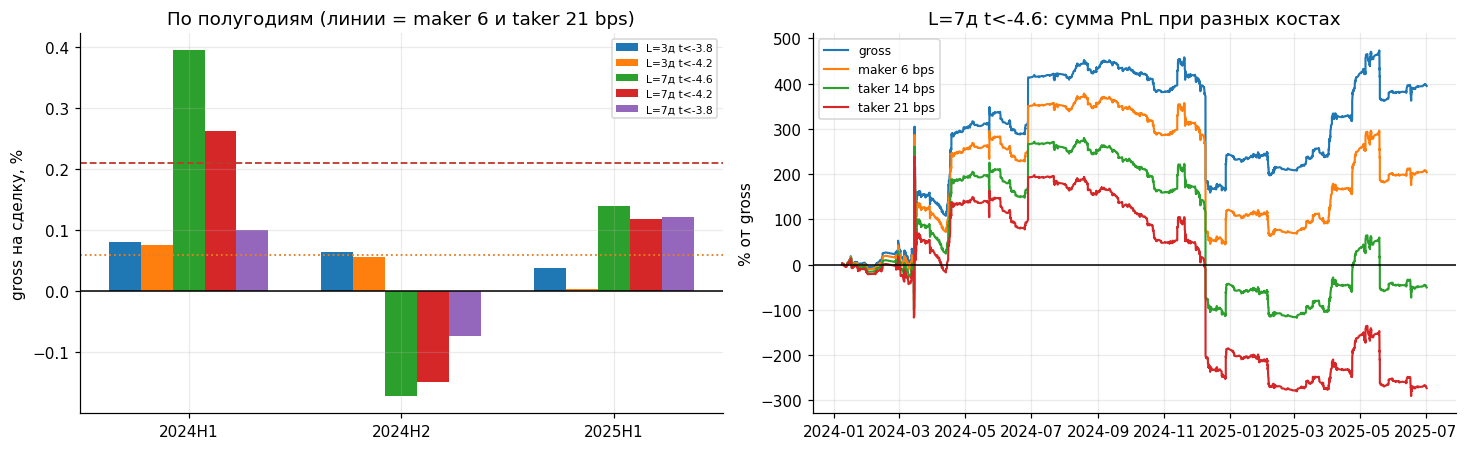

In [4]:
rows = []
SEG = [("2024H1", "2024-01-01", "2024-07-01"), ("2024H2", "2024-07-01", "2025-01-01"),
       ("2025H1", "2025-01-01", "2025-07-01")]
for (L, thr), d in TR.items():
    for nm, a, b in SEG:
        m = (d.t_in >= pd.Timestamp(a, tz="UTC")) & (d.t_in < pd.Timestamp(b, tz="UTC"))
        if m.sum() < 30:
            continue
        dd = d[m]
        pm = dd.groupby("pair").gross.mean()
        rows.append({"L, дн": L, "порог": thr, "период": nm, "сделок": len(dd),
                     "gross %": round(dd.gross.mean(), 4),
                     "медиана пары %": round(float(pm.median()), 4),
                     "% плюс": round((dd.gross > 0).mean()*100, 1),
                     "t кластер": round(float(pm.mean()/(pm.std(ddof=1)/np.sqrt(len(pm)))), 2)})
TS = pd.DataFrame(rows)
print("ПО ПОЛУГОДИЯМ")
print(TS.to_string(index=False))
print()
for (L, thr), _ in TR.items():
    d = TS[(TS["L, дн"] == L) & (TS["порог"] == thr)]
    if len(d) == 3:
        print(f"L={L}д t<{thr}: {list(d['gross %'])} -> "
              f"{'все три положительны' if (d['gross %']>0).all() else 'НЕ во всех отрезках'}")

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.2))
w = 0.15
for k, ((L, thr), _) in enumerate(TR.items()):
    d = TS[(TS["L, дн"] == L) & (TS["порог"] == thr)]
    ax[0].bar(np.arange(len(d)) + k*w, d["gross %"], width=w, label=f"L={L}д t<{thr}")
ax[0].set_xticks(np.arange(3) + w*2); ax[0].set_xticklabels([s[0] for s in SEG])
ax[0].axhline(0, color="black", lw=1); ax[0].axhline(0.06, color="#e67e22", ls=":", lw=1.2)
ax[0].axhline(0.21, color="#c0392b", ls="--", lw=1.2)
ax[0].set_ylabel("gross на сделку, %"); ax[0].legend(fontsize=7)
ax[0].set_title("По полугодиям (линии = maker 6 и taker 21 bps)")
d = TR[(7, -4.6)].sort_values("t_in")
for c, lab in [(0.0, "gross"), (0.06, "maker 6 bps"), (0.14, "taker 14 bps"), (0.21, "taker 21 bps")]:
    ax[1].plot(d.t_in.values, (d.gross - c).cumsum().values, lw=1.4, label=lab)
ax[1].axhline(0, color="black", lw=1); ax[1].legend(fontsize=8)
ax[1].set_title("L=7д t<-4.6: сумма PnL при разных костах"); ax[1].set_ylabel("% от gross")
show("nb10_time")

## 4. Экономика выжившего

In [5]:
years = (bk.index[-1] - bk.index[0]).days / 365.25
F_POS = 0.02
print(f"TRAIN = {years:.2f} года, gross позиции {F_POS*100:.0f}% капитала\n")
rows = []
for (L, thr), d in TR.items():
    for tag, TOX in [("все символы", []), ("без TRB/XMR", TOXIC)]:
        dd = d if not TOX else d[~d.pair.str.contains("|".join(TOX))]
        if len(dd) < 30:
            continue
        g = dd.gross.mean()
        n_yr = len(dd)/years
        r = {"L, дн": L, "порог": thr, "набор": tag, "сделок/год": int(n_yr),
             "gross %": round(g, 4), "б/у кост bps": round(g*100, 1)}
        for nm, c in [("taker 21", 0.21), ("taker 14", 0.14), ("maker 6", 0.06), ("maker 3", 0.03)]:
            r[nm + " %/год"] = round(n_yr*F_POS*(g-c), 1)
        rows.append(r)
EC = pd.DataFrame(rows)
print("ДОХОДНОСТЬ КАПИТАЛА ПРИ РАЗНЫХ КОСТАХ (оценка сверху по обороту)")
print(EC.to_string(index=False))
print()
print("Это оценка СВЕРХУ: она не учитывает лимит суммарного gross <= 100% и")
print("просадку, а также предполагает, что все сигналы исполнимы. Полная")
print("портфельная симуляция с очередью по |z| — следующий шаг.")
print()
best = EC.sort_values("maker 6 %/год", ascending=False).head(3)
print("ТРИ ЛУЧШИЕ КОНФИГУРАЦИИ ПО maker-СЦЕНАРИЮ:")
print(best.to_string(index=False))

TRAIN = 1.50 года, gross позиции 2% капитала

ДОХОДНОСТЬ КАПИТАЛА ПРИ РАЗНЫХ КОСТАХ (оценка сверху по обороту)
 L, дн  порог       набор  сделок/год  gross %  б/у кост bps  taker 21 %/год  taker 14 %/год  maker 6 %/год  maker 3 %/год
     3   -3.8 все символы       17129   0.0599           6.0           -51.4           -27.4           -0.0           10.2
     3   -3.8 без TRB/XMR       14591   0.0421           4.2           -49.0           -28.6           -5.2            3.5
     3   -4.2 все символы        7955   0.0452           4.5           -26.2           -15.1           -2.4            2.4
     3   -4.2 без TRB/XMR        6791   0.0251           2.5           -25.1           -15.6           -4.7           -0.7
     7   -4.6 все символы        2122   0.1241          12.4            -3.6            -0.7            2.7            4.0
     7   -4.6 без TRB/XMR        1507  -0.0422          -4.2            -7.6            -5.5           -3.1           -2.2
     7   -4.2 все символы   

## 5. Итог

In [6]:
print("ПРОВЕРКИ\n")
for (L, thr), d in TR.items():
    b = BT[(BT["L, дн"] == L) & (BT["порог"] == thr)].iloc[0]
    lo = LOO[(LOO["L, дн"] == L) & (LOO["порог"] == thr)].iloc[0]
    ts = TS[(TS["L, дн"] == L) & (TS["порог"] == thr)]
    mm = ~d.pair.str.contains("|".join(TOXIC))
    print(f"L={L}д t<{thr}: gross {d.gross.mean():+.4f}%  CI [{b['CI 2.5%']:+.4f}, {b['CI 97.5%']:+.4f}]")
    print(f"   P(>0)={b['P(gross>0)']:.2f}  P(>maker 6bps)={b['P(gross>0.06)']:.2f}  "
          f"P(>taker 21bps)={b['P(gross>0.21)']:.3f}")
    print(f"   без любого одного символа остаётся >0: {lo['остаётся >0 без любого']}; "
          f"без TRB/XMR: {d[mm].gross.mean():+.4f}%")
    print(f"   полугодий с плюсом: {(ts['gross %']>0).sum()} из {len(ts)}")
    print()

ПРОВЕРКИ

L=3д t<-3.8: gross +0.0599%  CI [+0.0398, +0.0793]
   P(>0)=1.00  P(>maker 6bps)=0.49  P(>taker 21bps)=0.000
   без любого одного символа остаётся >0: True; без TRB/XMR: +0.0421%
   полугодий с плюсом: 3 из 3

L=3д t<-4.2: gross +0.0452%  CI [+0.0140, +0.0759]
   P(>0)=1.00  P(>maker 6bps)=0.18  P(>taker 21bps)=0.000
   без любого одного символа остаётся >0: True; без TRB/XMR: +0.0251%
   полугодий с плюсом: 3 из 3

L=7д t<-4.6: gross +0.1241%  CI [+0.0439, +0.2023]
   P(>0)=1.00  P(>maker 6bps)=0.94  P(>taker 21bps)=0.016
   без любого одного символа остаётся >0: True; без TRB/XMR: -0.0422%
   полугодий с плюсом: 2 из 3

L=7д t<-4.2: gross +0.0784%  CI [+0.0311, +0.1253]
   P(>0)=1.00  P(>maker 6bps)=0.78  P(>taker 21bps)=0.000
   без любого одного символа остаётся >0: True; без TRB/XMR: -0.0286%
   полугодий с плюсом: 2 из 3

L=7д t<-3.8: gross +0.0508%  CI [+0.0154, +0.0853]
   P(>0)=1.00  P(>maker 6bps)=0.30  P(>taker 21bps)=0.000
   без любого одного символа остаётся >0: